## All the imports
import data set and all libraries that will be used later


In [32]:
import pandas as pd

from matplotlib import pyplot as plt 
%matplotlib inline

import numpy as np

import seaborn as sb

from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# models
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# path to the file to read
pcos_file_path = 'data\data without infertility _final.csv'

pcos_data = pd.read_csv(pcos_file_path) 

## Data info
seeing some statistics about the data

In [ ]:
pcos_data.info()

In [7]:
pcos_data.columns = pcos_data.columns.str.strip()
# to remove uneceserry spaces

In [ ]:
pcos_data.info()

In [ ]:
#to see empty data ; in our case it is col 42
sb.heatmap(pcos_data.isnull())

## Cleaning data
We have to remove null values and all values should be numerical

In [8]:
#dropping col that has all null values, and then id cols cause they are not needed for the clasification
#axis=1 is for col axis=0 is for rows
pcos_data.drop(["Unnamed: 42", "Sl. No", "Patient File No."], axis=1, inplace=True)

<Axes: >

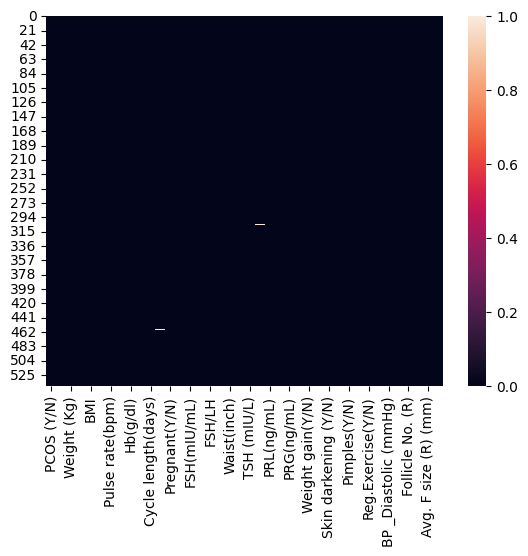

In [9]:
sb.heatmap(pcos_data.isnull())

In [10]:
pcos_data.isnull().sum()

PCOS (Y/N)               0
Age (yrs)                0
Weight (Kg)              0
Height(Cm)               0
BMI                      0
Blood Group              0
Pulse rate(bpm)          0
RR (breaths/min)         0
Hb(g/dl)                 0
Cycle(R/I)               0
Cycle length(days)       0
Marraige Status (Yrs)    1
Pregnant(Y/N)            0
No. of aborptions        0
FSH(mIU/mL)              0
LH(mIU/mL)               0
FSH/LH                   0
Hip(inch)                0
Waist(inch)              0
Waist:Hip Ratio          0
TSH (mIU/L)              0
AMH(ng/mL)               1
PRL(ng/mL)               0
Vit D3 (ng/mL)           0
PRG(ng/mL)               0
RBS(mg/dl)               0
Weight gain(Y/N)         0
hair growth(Y/N)         0
Skin darkening (Y/N)     0
Hair loss(Y/N)           0
Pimples(Y/N)             0
Fast food (Y/N)          1
Reg.Exercise(Y/N)        0
BP _Systolic (mmHg)      0
BP _Diastolic (mmHg)     0
Follicle No. (L)         0
Follicle No. (R)         0
A

In [11]:
pcos_data["Cycle(R/I)"] = pcos_data["Cycle(R/I)"].map({
    2: 0,  # Regular
    4: 1   # Irregular
})
# Channging the value of Irregular/regular cycles

### Setting features

In [12]:
hormone_features = [
    "FSH(mIU/mL)",
    "LH(mIU/mL)",
    "FSH/LH",
    "AMH(ng/mL)",
    "TSH (mIU/L)",
    "PRL(ng/mL)",
    "PRG(ng/mL)"  
]

In [13]:
patient_observable_features = [
    "Age (yrs)",
    "Weight (Kg)",
    "Height(Cm)",
    "Pregnant(Y/N)",
    "No. of aborptions",
    "Cycle(R/I)",             # Regular/Irregular periods
    "Cycle length(days)",     # length of period
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)"       # lifestyle activity
]

In [14]:
doctor_observable_features = [
    # Patient-reported symptoms
    "Cycle(R/I)",
    "Cycle length(days)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)",
    
    # Doctor-observed measurements
    "Weight (Kg)",
    "Height(Cm)",
    "BMI",
    "Pulse rate(bpm)",
    "RR (breaths/min)",
    "Hb(g/dl)",
    "Hip(inch)",
    "Waist(inch)",
    "Waist:Hip Ratio",
    "BP _Systolic (mmHg)",
    "BP _Diastolic (mmHg)",
    
    # Ultrasound / gynecologist measurements
    "Follicle No. (L)",
    "Follicle No. (R)",
    "Avg. F size (L) (mm)",
    "Avg. F size (R) (mm)",
    "Endometrium (mm)"
]


In [15]:
# all features except ids and target
# all_features = pcos_data.drop(columns=['PCOS (Y/N)'], axis=1)

all_features = list(pcos_data.drop(columns=['PCOS (Y/N)']).columns)

print(all_features)


['Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)']


Assigning what features we wanna use

In [16]:
pcos_features = all_features

Last cleaning data procces is removing null values from feature list

In [17]:
# dropna drops missing values (think of na as "not available")
pcos_data = pcos_data.dropna(
    subset=pcos_features + ["PCOS (Y/N)"]
)
#drop a row only if one of features or pcos label is missing

In [18]:
pcos_data[pcos_features].isnull().sum()


Age (yrs)                0
Weight (Kg)              0
Height(Cm)               0
BMI                      0
Blood Group              0
Pulse rate(bpm)          0
RR (breaths/min)         0
Hb(g/dl)                 0
Cycle(R/I)               0
Cycle length(days)       0
Marraige Status (Yrs)    0
Pregnant(Y/N)            0
No. of aborptions        0
FSH(mIU/mL)              0
LH(mIU/mL)               0
FSH/LH                   0
Hip(inch)                0
Waist(inch)              0
Waist:Hip Ratio          0
TSH (mIU/L)              0
AMH(ng/mL)               0
PRL(ng/mL)               0
Vit D3 (ng/mL)           0
PRG(ng/mL)               0
RBS(mg/dl)               0
Weight gain(Y/N)         0
hair growth(Y/N)         0
Skin darkening (Y/N)     0
Hair loss(Y/N)           0
Pimples(Y/N)             0
Fast food (Y/N)          0
Reg.Exercise(Y/N)        0
BP _Systolic (mmHg)      0
BP _Diastolic (mmHg)     0
Follicle No. (L)         0
Follicle No. (R)         0
Avg. F size (L) (mm)     0
A

## Separating predictor and targets

In [19]:
# By convention, this data (features) is called X.
X = pcos_data[pcos_features]

In [20]:
# want to predict if paitent has pcos or no
y = pcos_data["PCOS (Y/N)"]

In [21]:
X.head()

,Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,28,44.6,152.0,19.300000,15,78,22,10.48,0.0,5,7.0,0,0,7.95,3.68,2.160326,36,30,0.833333,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,36,65.0,161.5,24.921163,15,74,20,11.70,0.0,5,11.0,1,0,6.73,1.09,6.174312,38,32,0.842105,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,33,68.8,165.0,25.270891,11,72,18,11.80,0.0,5,10.0,1,0,5.54,0.88,6.295455,40,36,0.900000,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,37,65.0,148.0,29.674945,13,72,20,12.00,0.0,5,4.0,0,0,8.06,2.36,3.415254,42,36,0.857143,16.41,1.22,36.90,33.4,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,25,52.0,161.0,20.060954,11,72,18,10.00,0.0,5,1.0,1,0,3.98,0.90,4.422222,37,30,0.810811,3.57,2.26,30.09,43.8,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0


In [22]:
y.value_counts()

PCOS (Y/N)
0    362
1    175
Name: count, dtype: int64

<Axes: ylabel='count'>

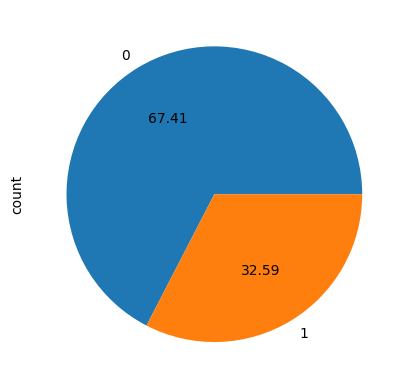

In [23]:
y.value_counts().plot.pie(autopct='%.2f')

## Spliting data into train and test

In [24]:
#the function train_test_split returns 4 diff values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=67)
# if you ever want to repeat the same split, you have to repeat random_state num
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=67)

# always change this value when you change it in the function so that you can log it later
test_size=0.25


## Scale the data - normalize 

In [25]:
#create a scaler object so that we can normalize the data
scaler = StandardScaler()

# fit the scaler to the data and then transform the data
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
X_val = scaler.fit_transform(X_val)


# Logistic Regression

## Train the model

In [ ]:
logistic_model = LogisticRegression(
    class_weight={0: 1, 1: 1},
    max_iter=500
)
# missing pcos patients is worse than misclassifying a non PCOS-patient
# so the clas 1 weights twice more than class 0

#actually train the model
logistic_model.fit(X_train, y_train)

In [ ]:
y_probs = logistic_model.predict_proba(X_test)[:, 1]


In [ ]:
threshold = 0.7
y_predictions = (y_probs >= threshold).astype(int)

## Evaluation

In [ ]:

print(classification_report(y_test, y_predictions))

In [ ]:
accuracy = accuracy_score(y_test, y_predictions)

print(f"Accuracy: {accuracy: .4f}")

In [ ]:
confusion_matrix(y_test, y_predictions)

## Logs how each split and feature list perfomed


had help of ai with this specific loggins system becasue i am still learning py syntax

In [ ]:
import os
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score

# --- Path ---
log_path = r'logs\experiment_log.csv'
os.makedirs(os.path.dirname(log_path), exist_ok=True)

# --- Standard feature sets ---
feature_sets = {
    "hormone_features": hormone_features,
    "patient_observable_features": patient_observable_features,
    "doctor_observable_features": doctor_observable_features,
    "all_features": all_features
}

# --- Auto-detect feature set label ---
def get_feature_set_label(features, feature_sets):
    for label, columns in feature_sets.items():
        if set(features) == set(columns):
            return label
    return "custom_features"

# --- Load or initialize log ---
columns = [
    "Model", "Feature_Set", "Test_Size", "Class_Weight", "Threshold",
    "Accuracy", "Precision", "Recall", "TN", "FP", "FN", "TP", "F1_Score"
]

try:
    experiment_log = pd.read_csv(log_path)
except (pd.errors.EmptyDataError, FileNotFoundError):
    experiment_log = pd.DataFrame(columns=columns)

# --- Grab info automatically from code ---
model_name = type(logistic_model).__name__
feature_set_label = get_feature_set_label(pcos_features, feature_sets)
class_weight = getattr(logistic_model, "class_weight", None)


accuracy = accuracy_score(y_test, y_predictions)
precision = precision_score(y_test, y_predictions)
recall = recall_score(y_test, y_predictions)
f1 = f1_score(y_test, y_predictions)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_predictions).ravel()

# --- Create log entry ---
new_entry = pd.DataFrame([{
    "Model": model_name,
    "Feature_Set": feature_set_label,
    "Test_Size": test_size,
    "Class_Weight": class_weight,
    "Threshold": threshold,
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp,
    "F1_Score": round(f1, 4)
}])

# --- Append and save ---
experiment_log = pd.concat([experiment_log, new_entry], ignore_index=True)
experiment_log.to_csv(log_path, index=False)

print(f"Experiment logged successfully! Feature set: {feature_set_label}")


# Random Forest Classifier

## Train the model


In [28]:
rf_model = RandomForestClassifier(random_state=67)

rf_model.fit(X_train, y_train)

y_predictions_rf = rf_model.predict(X_val)

rf_val_accuracy = accuracy_score(y_val, y_predictions_rf)

print(f"Accuracy: {rf_val_accuracy: .4f}")

print("\nClassification report:\n", classification_report(y_val, y_predictions_rf))

print("\nConfusion matrix:\n",confusion_matrix(y_val, y_predictions_rf))


Accuracy:  0.8642

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.94      0.90        50
           1       0.88      0.74      0.81        31

    accuracy                           0.86        81
   macro avg       0.87      0.84      0.85        81
weighted avg       0.87      0.86      0.86        81


Confusion matrix:
 [[47  3]
 [ 8 23]]


In [ ]:
param_grid = {
    'n_estimators': [10, 100, 200, 300],  
    'max_depth': [3, 5, 10, 20, None],       
    'max_features':["sqrt", "log2", None],    
    'min_samples_leaf': [1, 2, 4],              
    'bootstrap': [True, False]  
}
#dictionary with parameters names (str) as keys and lists of parameter settings

rf_model = RandomForestClassifier(random_state=67)

#scoring strategy to evaluate the performance of the cross-validated model on the test set.
#n_jobs -> -1 means using all processors
#verbose : Controls the verbosity: the higher, the more messages. ( опширност )
grid_search = GridSearchCV(rf_model, param_grid, cv=10, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best parameters: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

Fitting 10 folds for each of 360 candidates, totalling 3600 fits
Best parameters:  {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Best score:  0.9158143939393939


## Evaluation

In [30]:
y_predictions_rf = best_rf.predict(X_test)

test_accuracy = accuracy_score(y_test, y_predictions_rf)
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_predictions_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_predictions_rf))

Test Accuracy: 0.8815

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92        97
           1       0.78      0.82      0.79        38

    accuracy                           0.88       135
   macro avg       0.85      0.86      0.86       135
weighted avg       0.88      0.88      0.88       135


Confusion Matrix:
 [[88  9]
 [ 7 31]]


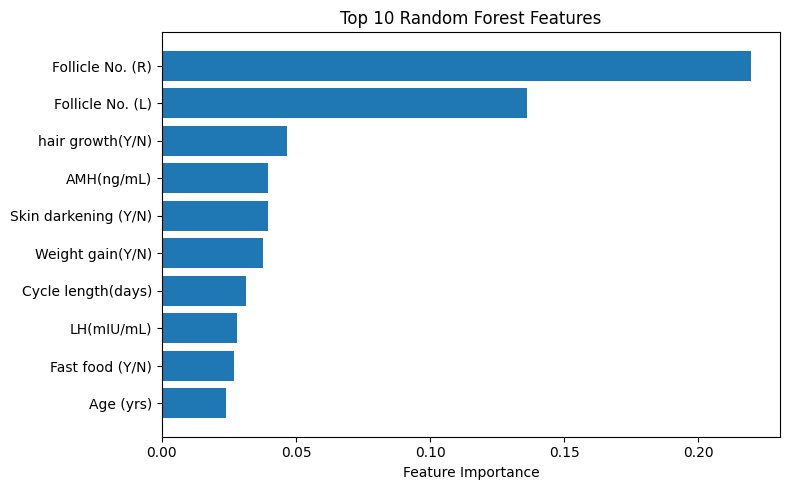

In [34]:
top_k = 10
indices = sorted_indices[:top_k]

plt.figure(figsize=(8, 5))
plt.barh(
    np.array(feature_names)[indices][::-1],
    feature_importances[indices][::-1]
)
plt.xlabel("Feature Importance")
plt.title("Top 10 Random Forest Features")
plt.tight_layout()
plt.show()


# Artificial Neural Network